First, we'll import the necessary libraries: OpenCV for image processing and Matplotlib for displaying the results. We will also load the pre-trained Haar cascade classifiers for face and eye detection.

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the Haar cascade classifiers for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

if face_cascade.empty():
    print("Error: Face cascade not loaded. Check the path.")
if eye_cascade.empty():
    print("Error: Eye cascade not loaded. Check the path.")


Next, we'll define a function that takes an image as input, converts it to grayscale, detects faces, and then within each detected face, detects eyes. It will draw rectangles around the detected faces and eyes.

In [2]:
def detect_eyes(image_path):
    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    print(f"Found {len(faces)} face(s)")

    # For each face, detect eyes
    for (x, y, w, h) in faces:
        # Draw rectangle around the face
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle for face

        # Region of interest for face in grayscale and color
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        # Detect eyes in the face region
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.05,
            minNeighbors=5,
            minSize=(20, 20),
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        print(f"  Found {len(eyes)} eye(s) in this face")

        # Draw rectangle around the eyes
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green rectangle for eyes

    # Convert BGR image to RGB for displaying with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the result
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title('Detected Faces and Eyes')
    plt.axis('off')
    plt.show()


Finally, we'll call our `detect_eyes` function with a sample image. Please replace `'test_image.jpg'` with the actual path to your image file. You can upload an image to your Colab environment or provide a URL.

Found 1 face(s)
  Found 7 eye(s) in this face


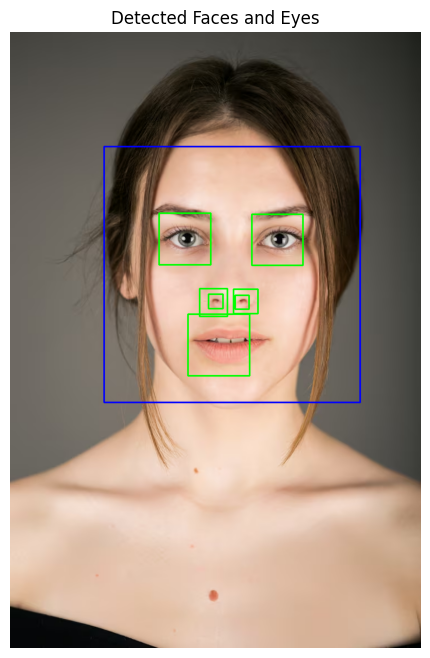

In [3]:
# Example usage:
# Make sure to upload an image file (e.g., 'test_image.jpg') to your Colab environment
# or provide a full path to an image.
image_file = 'face image.avif' # Replace with your image file name or path

detect_eyes(image_file)
